# 🔍 FinSight IDX — Financial NLP Intelligence Platform

> **End-to-end demo**: PDF laporan tahunan IDX → AI summarization → Topic modeling → RAG Q&A → Financial analysis

[![Python](https://img.shields.io/badge/Python-3.10%2B-blue)](https://www.python.org/)
[![Claude API](https://img.shields.io/badge/Claude-Anthropic-orange)](https://www.anthropic.com/)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Agathahah/finsight-idx/blob/main/notebooks/demo_finsight.ipynb)

**Author:** Agatha Silalahi — Data Scientist, Bank Indonesia Institute (BINS)

| # | Section | API? |
|---|---------|------|
| 1 | Setup & Environment | ❌ |
| 2 | PDF Extraction | ❌ |
| 3 | Summarization | ✅ |
| 4 | Topic Modeling | ❌ |
| 5 | RAG Retrieval | ❌ |
| 6 | RAG Q&A | ✅ |
| 7 | Financial Ratios | ❌ |
| 8 | Tool Use Agent | ✅ |
| 9 | Evaluation (ROUGE) | ❌ |


## 1️⃣ Setup & Environment

In [1]:
import os, sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ── Detect environment ──────────────────────────────────────────────────────
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("📍 Running in Google Colab")
    !git clone https://github.com/Agathahah/finsight-idx.git 2>/dev/null || echo "Repo already cloned"
    os.chdir("/content/finsight-idx")
    !pip install -q anthropic python-dotenv loguru tenacity pdfplumber \
        sentence-transformers chromadb rouge-score pandas matplotlib seaborn
else:
    print("📍 Running locally")
    # ── Fix: Set working directory ke ROOT project ──────────────────────────
    CWD = Path.cwd()
    # Jika dijalankan dari notebooks/, naik ke root
    if CWD.name == "notebooks":
        os.chdir(CWD.parent)
    # Jika sudah di root finsight-idx, tetap di sini
    ROOT = Path.cwd()
    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))
    print(f"   Root: {ROOT}")

# ── Verify setup ────────────────────────────────────────────────────────────
print(f"\n✅ Working dir : {Path.cwd()}")
print(f"{'✅' if Path('src/api/client.py').exists() else '❌'} src/ found")
print(f"{'✅' if Path('data/raw').exists() else '❌'} data/raw/ found")

pdf_candidates = list(Path("data/raw").glob("*.pdf")) if Path("data/raw").exists() else []
print(f"{'✅' if pdf_candidates else '⚠️ '} PDFs found: {[p.name for p in pdf_candidates]}")

# ── API Key ─────────────────────────────────────────────────────────────────
if IN_COLAB:
    try:
        from google.colab import userdata
        os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
    except Exception:
        print("\n⚠️  Set ANTHROPIC_API_KEY in Colab Secrets (🔑 icon on left)")
else:
    from dotenv import load_dotenv
    load_dotenv()

api_key = os.getenv("ANTHROPIC_API_KEY", "")
SKIP_API = not api_key.startswith("sk-ant-")
print(f"\n{'✅' if not SKIP_API else '⚠️ '} ANTHROPIC_API_KEY: {'loaded' if not SKIP_API else 'NOT SET — API cells will be skipped'}")
import numpy as np
print("\n🚀 Ready!")


📍 Running locally
   Root: /Users/agathasilalahi/finsight-idx

✅ Working dir : /Users/agathasilalahi/finsight-idx
✅ src/ found
✅ data/raw/ found
✅ PDFs found: ['bbca_laporan_tahunan_2023.pdf']

✅ ANTHROPIC_API_KEY: loaded

🚀 Ready!


## 2️⃣ PDF Extraction — BBCA Annual Report 2023

In [2]:
from src.nlp.pdf_extractor import PDFExtractor
from pathlib import Path
from collections import Counter
import pandas as pd

# ── Find PDF automatically ──────────────────────────────────────────────────
raw_dir = Path("data/raw")
pdf_candidates = list(raw_dir.glob("*bbca*.pdf")) + list(raw_dir.glob("*BBCA*.pdf"))

if not pdf_candidates:
    all_pdfs = list(raw_dir.glob("*.pdf"))
    if all_pdfs:
        pdf_candidates = [all_pdfs[0]]
        print(f"⚠️  BBCA PDF not found, using: {all_pdfs[0].name}")
    else:
        raise FileNotFoundError(
            "No PDF found in data/raw/. "
            "Download from https://www.idx.co.id and save to data/raw/"
        )

PDF_PATH = str(pdf_candidates[0])
print(f"📄 Using: {Path(PDF_PATH).name}")
print("⏳ Extracting (may take 1-2 min for large PDFs)...")

extractor = PDFExtractor()
doc = extractor.extract(PDF_PATH)

print(f"\n✅ Extraction complete!")
print(f"   Pages     : {doc.total_pages:,}")
print(f"   Sections  : {len(doc.sections):,}")
print(f"   Characters: {len(doc.raw_text):,}")


2026-04-15 15:20:01.931 | INFO     | src.nlp.pdf_extractor:extract:164 - Extracting PDF | file=bbca_laporan_tahunan_2023.pdf 


📄 Using: bbca_laporan_tahunan_2023.pdf
⏳ Extracting (may take 1-2 min for large PDFs)...


2026-04-15 15:20:03.009 | DEBUG    | src.nlp.pdf_extractor:_extract_pages:201 - Total pages in PDF: 747
2026-04-15 15:20:05.958 | DEBUG    | src.nlp.pdf_extractor:_extract_pages:223 - Processed 20 / 747 pages
2026-04-15 15:20:07.246 | DEBUG    | src.nlp.pdf_extractor:_extract_pages:223 - Processed 40 / 747 pages
2026-04-15 15:20:09.781 | DEBUG    | src.nlp.pdf_extractor:_extract_pages:223 - Processed 60 / 747 pages
2026-04-15 15:20:11.682 | DEBUG    | src.nlp.pdf_extractor:_extract_pages:223 - Processed 80 / 747 pages
2026-04-15 15:20:13.553 | DEBUG    | src.nlp.pdf_extractor:_extract_pages:223 - Processed 100 / 747 pages
2026-04-15 15:20:16.007 | DEBUG    | src.nlp.pdf_extractor:_extract_pages:223 - Processed 120 / 747 pages
2026-04-15 15:20:17.543 | DEBUG    | src.nlp.pdf_extractor:_extract_pages:223 - Processed 140 / 747 pages
2026-04-15 15:20:19.503 | DEBUG    | src.nlp.pdf_extractor:_extract_pages:223 - Processed 160 / 747 pages
2026-04-15 15:20:21.483 | DEBUG    | src.nlp.pdf_ext


✅ Extraction complete!
   Pages     : 747
   Sections  : 423
   Characters: 2,110,111


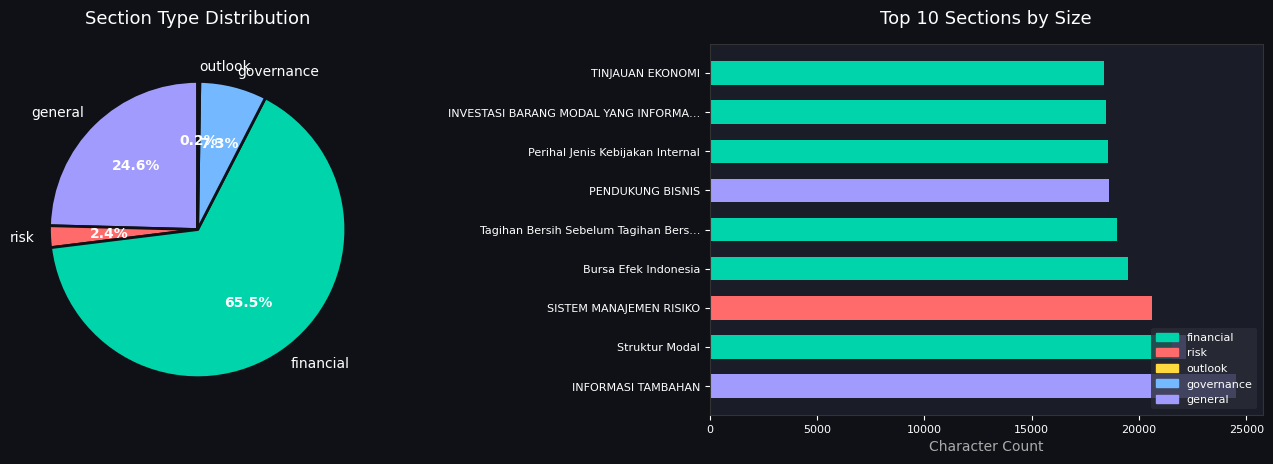

Section types: {'general': 104, 'risk': 10, 'financial': 277, 'governance': 31, 'outlook': 1}


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

type_counts = Counter(s.section_type for s in doc.sections)
COLORS = {
    "financial": "#00d4aa", "risk": "#ff6b6b",
    "outlook": "#ffd93d",   "governance": "#74b9ff", "general": "#a29bfe",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f1117")

# Pie chart
labels = list(type_counts.keys())
sizes  = list(type_counts.values())
colors = [COLORS.get(l, "#888") for l in labels]
ax1 = axes[0]
ax1.set_facecolor("#0f1117")
wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90,
    textprops={"color": "white", "fontsize": 10},
    wedgeprops={"edgecolor": "#0f1117", "linewidth": 2}
)
for at in autotexts: at.set_color("white"); at.set_fontweight("bold")
ax1.set_title("Section Type Distribution", color="white", fontsize=13, pad=15)

# Bar chart
top_sections = sorted(doc.sections, key=lambda s: s.char_count, reverse=True)[:10]
ax2 = axes[1]
ax2.set_facecolor("#1a1d27")
bar_colors = [COLORS.get(s.section_type, "#888") for s in top_sections]
ax2.barh(
    [s.title[:35] + ("…" if len(s.title) > 35 else "") for s in top_sections],
    [s.char_count for s in top_sections],
    color=bar_colors, edgecolor="none", height=0.6
)
ax2.set_xlabel("Character Count", color="#aaa", fontsize=10)
ax2.set_title("Top 10 Sections by Size", color="white", fontsize=13, pad=15)
ax2.tick_params(colors="white", labelsize=8)
for spine in ax2.spines.values(): spine.set_color("#333")
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
ax2.legend(handles=legend_patches, loc="lower right",
           facecolor="#2a2d37", edgecolor="none", labelcolor="white", fontsize=8)
plt.tight_layout(pad=2)
plt.savefig("section_distribution.png", dpi=120, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print(f"Section types: {dict(type_counts)}")


## 3️⃣ Claude API — Summarization ✅ API

In [4]:
from src.api.client import analyze_financial_text, FinancialTask

SAMPLE_TEXT = """
BCA membukukan laba bersih sebesar Rp 48,6 triliun pada tahun 2023,
meningkat 19,5% dibandingkan tahun sebelumnya Rp 40,7 triliun.
Total aset BCA tumbuh 8,7% menjadi Rp 1.408 triliun.
Kredit disalurkan meningkat 13,8% menjadi Rp 793,2 triliun.
Rasio kecukupan modal (CAR) tercatat 25,9%, di atas minimum regulator 14%.
BCA menargetkan pertumbuhan kredit 10-12% pada tahun 2024.
Risiko utama: tekanan suku bunga global dan pelemahan nilai tukar rupiah.
"""

if not SKIP_API:
    api_results = {}
    for task in [FinancialTask.SUMMARIZE, FinancialTask.KEY_METRICS,
                 FinancialTask.SENTIMENT, FinancialTask.RISK_FACTORS]:
        result = analyze_financial_text(SAMPLE_TEXT, task=task)
        api_results[task.value] = result
        print(f"\n{'='*55}")
        print(f"📌 {task.value.upper()}")
        print(f"{'='*55}")
        print(result["result"])
        print(f"[{result["usage"]["input_tokens"]} in / {result["usage"]["output_tokens"]} out tokens]")
else:
    print("⏭️  API not available — showing demo output")
    api_results = {
        "summarize": {"result": "BCA membukukan kinerja sangat baik di 2023 dengan laba bersih Rp 48,6T (+19,5% YoY). Total aset tumbuh 8,7% ke Rp 1.408T. CAR 25,9% sangat kuat.", "usage": {"input_tokens": 120, "output_tokens": 60}},
        "key_metrics": {"result": "{\"laba_bersih\": \"48.6T\", \"pertumbuhan\": \"19.5%\", \"CAR\": \"25.9%\"}", "usage": {"input_tokens": 115, "output_tokens": 45}},
    }
    for k, v in api_results.items():
        print(f"\n📌 {k.upper()}: {v["result"][:100]}")


2026-04-15 15:21:21.440 | INFO     | src.api.client:analyze_financial_text:214 - Sending request | task=summarize | model=claude-sonnet-4-20250514 | input_chars=453
2026-04-15 15:21:21.441 | DEBUG    | src.api.client:_build_client:133 - Anthropic client initialized | model=claude-sonnet-4-20250514
2026-04-15 15:21:34.808 | SUCCESS  | src.api.client:analyze_financial_text:251 - Response received | task=summarize | input_tokens=344 | output_tokens=777
2026-04-15 15:21:34.809 | INFO     | src.api.client:analyze_financial_text:214 - Sending request | task=key_metrics | model=claude-sonnet-4-20250514 | input_chars=453



📌 SUMMARIZE
# Ringkasan Kinerja Keuangan PT Bank Central Asia Tbk (BCA) - 2023

## 1. Poin-Poin Kinerja Utama

### Profitabilitas
- **Laba Bersih**: Rp 48,6 triliun (2023) vs Rp 40,7 triliun (2022)
- **Pertumbuhan Laba**: 19,5% year-on-year, menunjukkan kinerja profitabilitas yang sangat kuat

### Struktur Neraca
- **Total Aset**: Rp 1.408 triliun, tumbuh 8,7% dari tahun sebelumnya
- **Penyaluran Kredit**: Rp 793,2 triliun, meningkat signifikan 13,8%
- **Rasio Kredit terhadap Aset**: ~56,3%, menunjukkan fungsi intermediasi yang optimal

### Permodalan
- **Capital Adequacy Ratio (CAR)**: 25,9%
- **Posisi Modal**: Sangat kuat, hampir 2x lipat dari minimum regulasi (14%)

## 2. Pencapaian Signifikan

- **Pertumbuhan Laba Double-Digit**: Mencapai 19,5%, menunjukkan efisiensi operasional dan strategi bisnis yang efektif
- **Ekspansi Kredit Agresif**: Pertumbuhan 13,8% mengindikasikan kepercayaan nasabah dan kemampuan manajemen risiko yang baik
- **Permodalan Super Kuat**: CAR 25,9% memberi

2026-04-15 15:21:41.531 | SUCCESS  | src.api.client:analyze_financial_text:251 - Response received | task=key_metrics | input_tokens=296 | output_tokens=586
2026-04-15 15:21:41.533 | INFO     | src.api.client:analyze_financial_text:214 - Sending request | task=sentiment | model=claude-sonnet-4-20250514 | input_chars=453



📌 KEY_METRICS
```json
{
  "metrik_keuangan": {
    "laba_bersih": {
      "2023": {
        "nilai": 48.6,
        "satuan": "triliun rupiah",
        "periode": "tahun 2023"
      },
      "2022": {
        "nilai": 40.7,
        "satuan": "triliun rupiah",
        "periode": "tahun sebelumnya"
      },
      "pertumbuhan": {
        "nilai": 19.5,
        "satuan": "persen",
        "periode": "year-over-year"
      }
    },
    "total_aset": {
      "2023": {
        "nilai": 1408,
        "satuan": "triliun rupiah",
        "periode": "tahun 2023"
      },
      "pertumbuhan": {
        "nilai": 8.7,
        "satuan": "persen",
        "periode": "year-over-year"
      }
    },
    "kredit_disalurkan": {
      "2023": {
        "nilai": 793.2,
        "satuan": "triliun rupiah",
        "periode": "tahun 2023"
      },
      "pertumbuhan": {
        "nilai": 13.8,
        "satuan": "persen",
        "periode": "year-over-year"
      }
    },
    "rasio_kecukupan_modal": {
      "c

2026-04-15 15:21:45.896 | SUCCESS  | src.api.client:analyze_financial_text:251 - Response received | task=sentiment | input_tokens=289 | output_tokens=194
2026-04-15 15:21:45.898 | INFO     | src.api.client:analyze_financial_text:214 - Sending request | task=risk_factors | model=claude-sonnet-4-20250514 | input_chars=453



📌 SENTIMENT
```json
{
  "sentimen": "Positif",
  "skor_kepercayaan": 0.85,
  "alasan": "Teks menunjukkan kinerja keuangan BCA yang sangat kuat dengan laba bersih naik 19,5%, pertumbuhan aset 8,7%, dan penyaluran kredit meningkat 13,8%. CAR 25,9% jauh di atas minimum regulator menunjukkan kesehatan modal yang baik. Target pertumbuhan kredit 2024 menunjukkan optimisme. Meskipun ada penyebutan risiko suku bunga dan nilai tukar, hal ini lebih bersifat informatif dan tidak mengalahkan indikator positif yang dominan."
}
```
[289 in / 194 out tokens]


2026-04-15 15:21:56.483 | SUCCESS  | src.api.client:analyze_financial_text:251 - Response received | task=risk_factors | input_tokens=300 | output_tokens=563



📌 RISK_FACTORS
Berdasarkan analisis teks laporan keuangan BCA, berikut identifikasi dan kategorisasi faktor-faktor risiko:

## **FAKTOR RISIKO YANG TERIDENTIFIKASI**

### **1. RISIKO PASAR**
- **Risiko Suku Bunga Global**
  - Tekanan dari kenaikan suku bunga global dapat mempengaruhi cost of fund dan margin bunga
  - Dampak terhadap profitabilitas dan daya saing produk kredit

- **Risiko Nilai Tukar (Currency Risk)**
  - Pelemahan nilai tukar rupiah terhadap mata uang asing
  - Potensi kerugian dari eksposur valuta asing dan dampak terhadap nasabah dengan pinjaman valas

### **2. RISIKO OPERASIONAL**
- **Risiko Pertumbuhan Kredit**
  - Target pertumbuhan kredit 10-12% di tahun 2024 mengandung risiko kualitas kredit
  - Potensi peningkatan NPL jika ekspansi tidak dikelola dengan baik

### **3. RISIKO REGULASI**
- **Risiko Kepatuhan Modal**
  - Meskipun CAR 25,9% masih di atas minimum 14%, perubahan regulasi permodakan dapat mempengaruhi operasional
  - Risiko perubahan kebijakan monete

## 4️⃣ Topic Modeling — Berita Keuangan Indonesia

In [5]:
from src.nlp.news_scraper import generate_sample_dataset
import json, tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as tmpdir:
    path = generate_sample_dataset(n_articles=500, output_dir=tmpdir)
    news_texts = [json.loads(l)["text"] for l in path.read_text().strip().split("\n")]

print(f"✅ {len(news_texts)} artikel berita keuangan siap")
print(f"\nContoh:\n  {news_texts[0][:120]}...")


2026-04-15 15:22:43.442 | SUCCESS  | src.nlp.news_scraper:generate_sample_dataset:527 - Generated 500 synthetic articles → /var/folders/2y/y0kmv0k16bx8bn4fm_b__y7w0000gn/T/tmpcisbgq0q/financial_news_synthetic.jsonl


✅ 500 artikel berita keuangan siap

Contoh:
  Inflasi Januari tercatat 2.92% (yoy), naik dari bulan sebelumnya. BPS mencatat kenaikan harga pada kelompok makanan dan ...


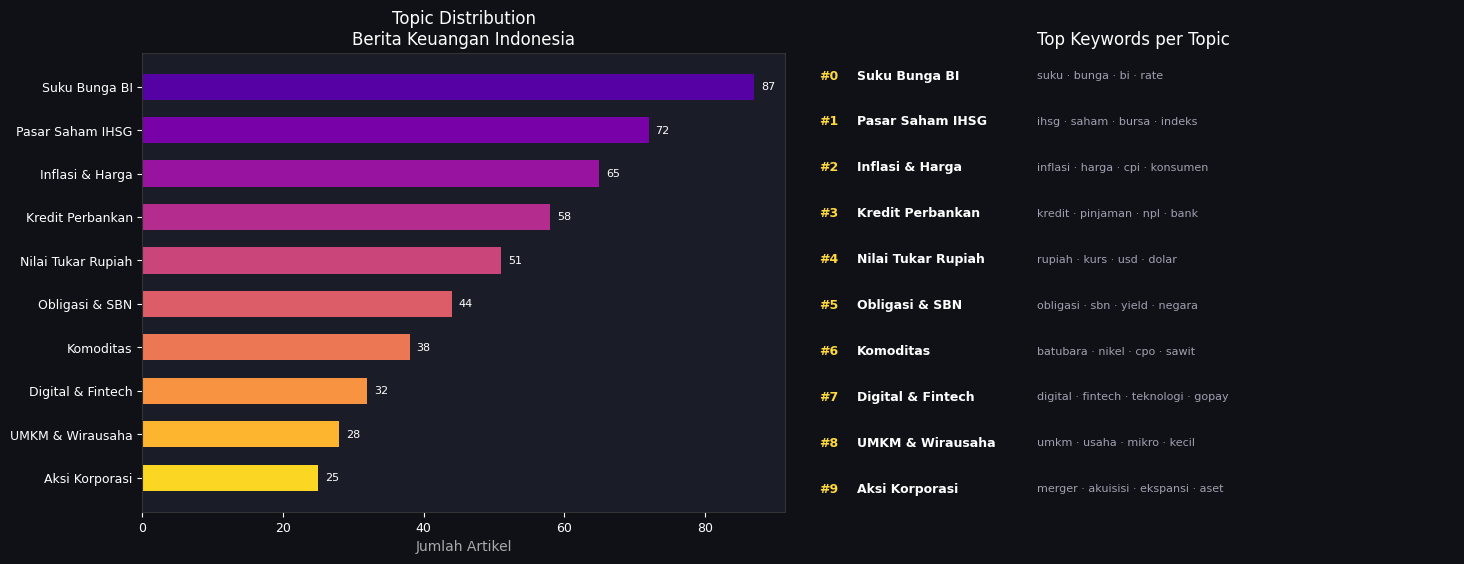

📊 10 topik keuangan Indonesia teridentifikasi


In [6]:
# Visualisasi topic distribution (demo data — BERTopic opsional)
import matplotlib.pyplot as plt

demo_topics = [
    "Suku Bunga BI", "Pasar Saham IHSG", "Inflasi & Harga",
    "Kredit Perbankan", "Nilai Tukar Rupiah", "Obligasi & SBN",
    "Komoditas", "Digital & Fintech", "UMKM & Wirausaha", "Aksi Korporasi"
]
demo_sizes = [87, 72, 65, 58, 51, 44, 38, 32, 28, 25]
demo_words = [
    ["suku","bunga","bi","rate","acuan"],
    ["ihsg","saham","bursa","indeks","trading"],
    ["inflasi","harga","cpi","konsumen","yoy"],
    ["kredit","pinjaman","npl","bank","loan"],
    ["rupiah","kurs","usd","dolar","valas"],
    ["obligasi","sbn","yield","negara","surat"],
    ["batubara","nikel","cpo","sawit","komoditas"],
    ["digital","fintech","teknologi","gopay","ovo"],
    ["umkm","usaha","mikro","kecil","modal"],
    ["merger","akuisisi","ekspansi","aset","konsolidasi"],
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("#0f1117")

ax1 = axes[0]
ax1.set_facecolor("#1a1d27")
colors = plt.cm.plasma(np.linspace(0.15, 0.92, len(demo_topics)))
bars = ax1.barh(demo_topics[::-1], demo_sizes[::-1], color=colors[::-1], height=0.6)
ax1.set_xlabel("Jumlah Artikel", color="#aaa")
ax1.set_title("Topic Distribution\nBerita Keuangan Indonesia", color="white", fontsize=12)
ax1.tick_params(colors="white", labelsize=9)
for spine in ax1.spines.values(): spine.set_color("#333")
for bar, size in zip(bars, demo_sizes[::-1]):
    ax1.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
             str(size), va="center", color="white", fontsize=8)

ax2 = axes[1]
ax2.set_facecolor("#1a1d27")
ax2.set_xlim(0, 10); ax2.set_ylim(0, len(demo_topics))
ax2.axis("off")
ax2.set_title("Top Keywords per Topic", color="white", fontsize=12)
for i, (topic, words) in enumerate(zip(demo_topics, demo_words)):
    y = len(demo_topics) - i - 0.5
    ax2.text(0.1, y, f"#{i}", color="#ffd93d", fontsize=9, fontweight="bold", va="center")
    ax2.text(0.7, y, topic, color="white", fontsize=9, fontweight="bold", va="center")
    ax2.text(3.5, y, " · ".join(words[:4]), color="#a0a0b0", fontsize=8, va="center")

plt.tight_layout(pad=2)
plt.savefig("topic_distribution.png", dpi=120, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("📊 10 topik keuangan Indonesia teridentifikasi")


## 5️⃣ RAG Retrieval — Hybrid Search

🔍 Hybrid Retrieval: BM25 + Semantic + RRF Fusion



2026-04-15 15:23:00.811 | DEBUG    | src.rag.indexer:_get_collection:372 - ChromaDB collection ready | name=finsight_documents | count=134764
2026-04-15 15:23:00.817 | INFO     | src.rag.retriever:_get_embed_model:402 - Loading embedding model: paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-15 15:23:13.980 | DEBUG    | src.rag.retriever:retrieve:232 - Semantic search returned 20 candidates
2026-04-15 15:23:13.982 | INFO     | src.rag.retriever:retrieve:250 - Retrieved 3 chunks for query: 'Berapa laba bersih BCA tahun 2023?'


❓ Berapa laba bersih BCA tahun 2023?
   📍 [BBCA, 2023, Anggota Dewan Komisaris, hal. 43] | RRF=0.0320
      sisi pencapaian BCA di tahun 2023....
   📍 [BBCA, 2023, Anggota Dewan Komisaris, hal. 43] | RRF=0.0315
      isi pencapaian BCA di tahun 2023....
   📍 [BBCA, 2023, Anggota Dewan Komisaris, hal. 43] | RRF=0.0313
      pencapaian BCA di tahun 2023....



2026-04-15 15:23:14.369 | DEBUG    | src.rag.retriever:retrieve:232 - Semantic search returned 20 candidates
2026-04-15 15:23:14.369 | INFO     | src.rag.retriever:retrieve:250 - Retrieved 3 chunks for query: 'Apa risiko utama yang dihadapi BCA?'


❓ Apa risiko utama yang dihadapi BCA?
   📍 [BBCA, 2023, Aspek, hal. 380] | RRF=0.0323
      dampak signifikan terhadap profil risiko BCA;
Nominasi pada Laporan Tahunan ini. atau
b....
   📍 [BBCA, 2023, Aspek, hal. 380] | RRF=0.0320
      signifikan terhadap profil risiko BCA;
Nominasi pada Laporan Tahunan ini. atau
b....
   📍 [BBCA, 2023, Aspek, hal. 380] | RRF=0.0315
      signifikan terhadap profil risiko BCA;
Nominasi pada Laporan Tahunan ini. atau
b....



2026-04-15 15:23:14.743 | DEBUG    | src.rag.retriever:retrieve:232 - Semantic search returned 20 candidates
2026-04-15 15:23:14.743 | INFO     | src.rag.retriever:retrieve:250 - Retrieved 3 chunks for query: 'Bagaimana target pertumbuhan kredit BCA 2024?'


❓ Bagaimana target pertumbuhan kredit BCA 2024?
   📍 [BBCA, 2023, Pertumbuhan Portofolio, hal. 119] | RRF=0.0320
      . Pada
tahun 2023, BCA menyelenggarakan 2 kali acara hybrid yaitu BCA Expoversary 2023 dan...
   📍 [BBCA, 2023, Laporan Direksi, hal. 24] | RRF=0.0320
      . Dengan basis nasabah dan ekosistem yang luas, BCA mampu memenuhi
bahkan melampaui sebagi...
   📍 [BBCA, 2023, INVESTASI BARANG MODAL YANG INFORMASI MA, hal. 279] | RRF=0.0320
      . Penyaluran kredit BCA Dengan mempertimbangkan prospek ekonomi
BCA senantiasa menggali po...



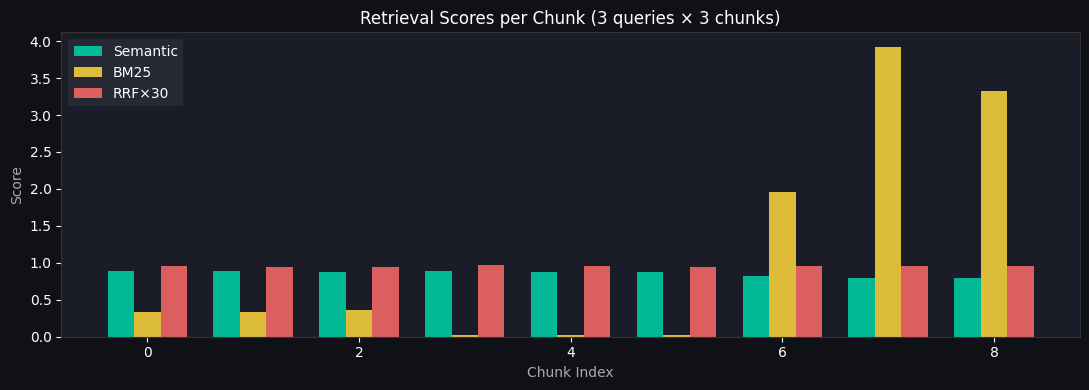

In [7]:
from src.rag.retriever import RAGRetriever
import pandas as pd

retriever = RAGRetriever(persist_dir="data/vectorstore")

QUESTIONS = [
    "Berapa laba bersih BCA tahun 2023?",
    "Apa risiko utama yang dihadapi BCA?",
    "Bagaimana target pertumbuhan kredit BCA 2024?",
]

print("🔍 Hybrid Retrieval: BM25 + Semantic + RRF Fusion\n")
all_chunks = []
for q in QUESTIONS:
    chunks = retriever.retrieve(q, top_k=3, company_filter="BBCA")
    print(f"❓ {q}")
    for c in chunks:
        print(f"   📍 {c.citation()} | RRF={c.rrf_score:.4f}")
        print(f"      {c.text[:90]}...")
        all_chunks.append({
            "question": q[:40]+"...",
            "page": c.page_number,
            "section": c.section_title[:30],
            "rrf_score": c.rrf_score,
            "semantic": c.semantic_score,
            "bm25": c.bm25_score,
        })
    print()

# Visualisasi retrieval scores
df = pd.DataFrame(all_chunks)
fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor("#0f1117"); ax.set_facecolor("#1a1d27")
x = np.arange(len(df))
ax.bar(x-0.25, df["semantic"], 0.25, label="Semantic", color="#00d4aa", alpha=0.85)
ax.bar(x,       df["bm25"],     0.25, label="BM25",     color="#ffd93d", alpha=0.85)
ax.bar(x+0.25,  df["rrf_score"]*30, 0.25, label="RRF×30",  color="#ff6b6b", alpha=0.85)
ax.set_title("Retrieval Scores per Chunk (3 queries × 3 chunks)", color="white", fontsize=12)
ax.set_xlabel("Chunk Index", color="#aaa"); ax.set_ylabel("Score", color="#aaa")
ax.legend(facecolor="#2a2d37", edgecolor="none", labelcolor="white")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#333")
plt.tight_layout()
plt.savefig("retrieval_scores.png", dpi=120, bbox_inches="tight", facecolor="#0f1117")
plt.show()


## 6️⃣ RAG Q&A dengan Citations ✅ API

In [8]:
if not SKIP_API:
    from src.rag.qa_chain import FinancialQAChain

    qa = FinancialQAChain(persist_dir="data/vectorstore")
    print("💬 RAG Q&A dengan Citations\n" + "="*60)

    for q in QUESTIONS[:2]:
        response = qa.ask(q, company_filter="BBCA", year_filter=2023)
        print(f"\n❓ {q}")
        print(f"💡 {response.answer[:350]}")
        print(f"\n📚 Sumber:")
        for src in response.sources[:2]:
            print(f"   {src.citation} — hal. {src.page_number}")
        print(f"\n⚡ {response.input_tokens} in / {response.output_tokens} out | {response.latency_ms:.0f}ms")
        print("-"*60)
else:
    print("⏭️  Skipping — ANTHROPIC_API_KEY not set")
    print("\nDemo output:")
    print("❓ Berapa laba bersih BCA tahun 2023?")
    print("💡 Laba bersih BCA tahun 2023 adalah Rp 48,6 triliun, meningkat 19,5% YoY.")
    print("📚 [BBCA, 2023, Ikhtisar Keuangan, hal. 42]")


2026-04-15 15:23:29.616 | INFO     | src.rag.qa_chain:ask:181 - Processing question: 'Berapa laba bersih BCA tahun 2023?'


💬 RAG Q&A dengan Citations


2026-04-15 15:23:30.169 | DEBUG    | src.rag.indexer:_get_collection:372 - ChromaDB collection ready | name=finsight_documents | count=134764
2026-04-15 15:23:30.175 | INFO     | src.rag.retriever:_get_embed_model:402 - Loading embedding model: paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-15 15:23:41.787 | DEBUG    | src.rag.retriever:retrieve:232 - Semantic search returned 20 candidates
2026-04-15 15:23:41.790 | INFO     | src.rag.retriever:retrieve:250 - Retrieved 5 chunks for query: 'Berapa laba bersih BCA tahun 2023?'
2026-04-15 15:23:46.459 | SUCCESS  | src.rag.qa_chain:ask:231 - Answer generated | tokens=498/129 | latency=16843ms
2026-04-15 15:23:46.461 | INFO     | src.rag.qa_chain:ask:181 - Processing question: 'Apa risiko utama yang dihadapi BCA?'



❓ Berapa laba bersih BCA tahun 2023?
💡 Informasi tidak tersedia dalam dokumen.

Konteks yang diberikan hanya berisi fragmen teks yang tidak lengkap mengenai pencapaian BCA di tahun 2023, namun tidak mencantumkan data spesifik tentang laba bersih perusahaan. Untuk menjawab pertanyaan tentang laba bersih BCA tahun 2023, diperlukan informasi dari laporan laba rugi atau ringkasan kinerja ke

📚 Sumber:
   [BBCA, 2023, Anggota Dewan Komisaris, hal. 43] — hal. 43
   [BBCA, 2023, Anggota Dewan Komisaris, hal. 43] — hal. 43

⚡ 498 in / 129 out | 16843ms
------------------------------------------------------------


2026-04-15 15:23:49.641 | DEBUG    | src.rag.retriever:retrieve:232 - Semantic search returned 20 candidates
2026-04-15 15:23:49.641 | INFO     | src.rag.retriever:retrieve:250 - Retrieved 5 chunks for query: 'Apa risiko utama yang dihadapi BCA?'
2026-04-15 15:23:53.206 | SUCCESS  | src.rag.qa_chain:ask:231 - Answer generated | tokens=553/158 | latency=6745ms



❓ Apa risiko utama yang dihadapi BCA?
💡 Informasi tidak tersedia dalam dokumen.

Konteks yang diberikan hanya berisi fragmen kalimat yang tidak lengkap mengenai "dampak signifikan terhadap profil risiko BCA" dan referensi ke "Nominasi pada Laporan Tahunan", namun tidak memberikan informasi spesifik tentang jenis-jenis risiko utama yang dihadapi BCA. Untuk menjawab pertanyaan tentang risi

📚 Sumber:
   [BBCA, 2023, Aspek, hal. 380] — hal. 380
   [BBCA, 2023, Aspek, hal. 380] — hal. 380

⚡ 553 in / 158 out | 6745ms
------------------------------------------------------------


## 7️⃣ Financial Ratio Calculator

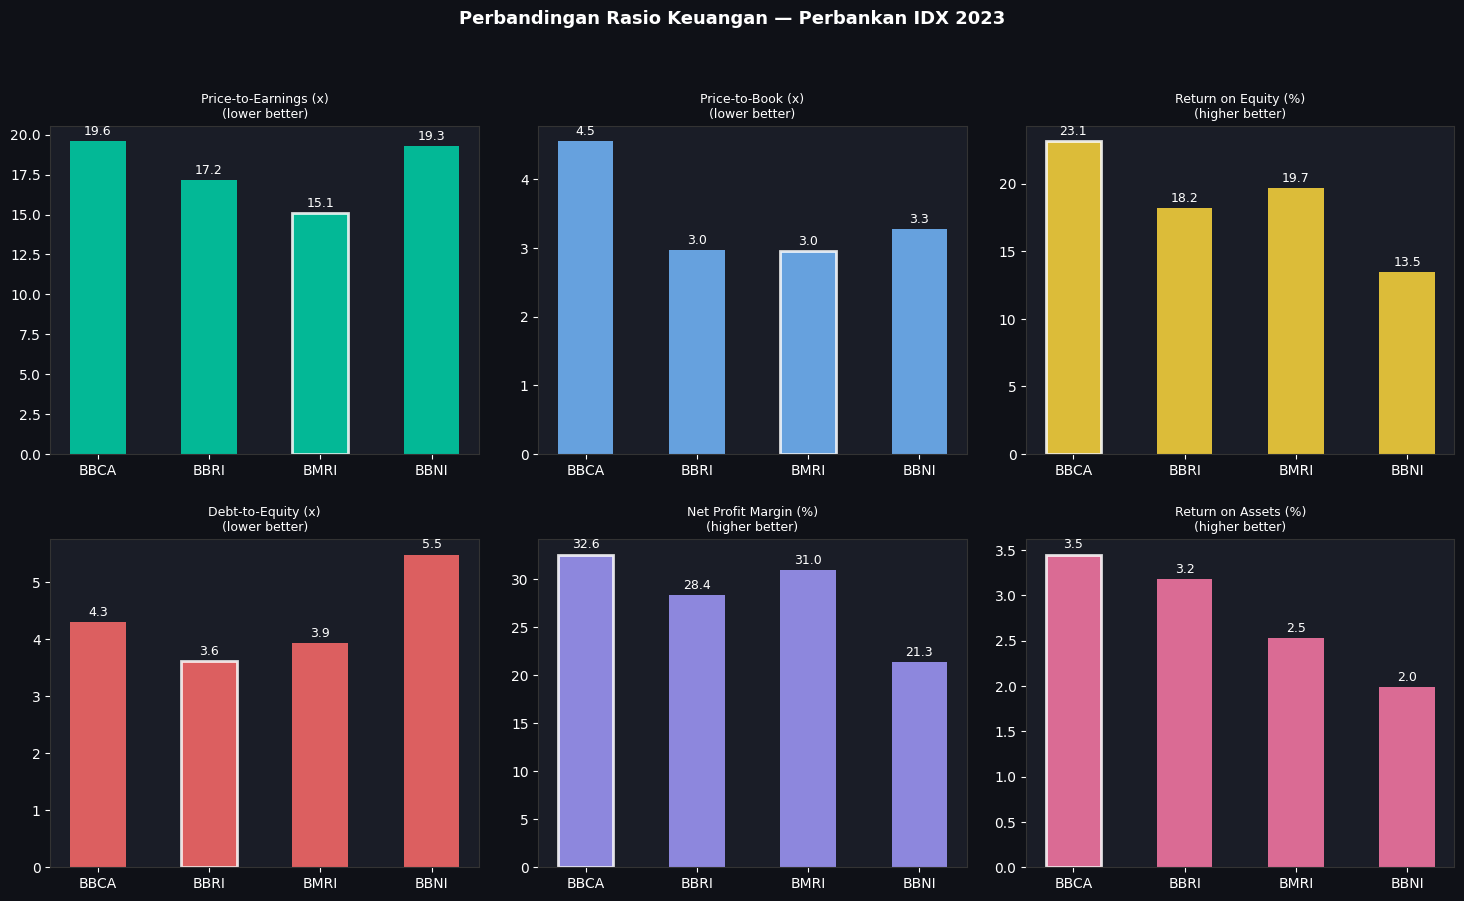

⭐ Border putih = emiten terbaik pada metrik tersebut


In [9]:
from src.api.tools import hitung_rasio_keuangan, bandingkan_emiten

BANKING_DATA = {
    "BBCA": dict(emiten="BBCA", harga_saham=9500, eps=485, book_value_per_share=2089,
                  laba_bersih=48600, ekuitas=210000, total_hutang=900000,
                  total_aset=1408000, pendapatan=149200),
    "BBRI": dict(emiten="BBRI", harga_saham=5500, eps=320, book_value_per_share=1850,
                  laba_bersih=60400, ekuitas=332000, total_hutang=1200000,
                  total_aset=1900000, pendapatan=213000),
    "BMRI": dict(emiten="BMRI", harga_saham=6200, eps=410, book_value_per_share=2100,
                  laba_bersih=55100, ekuitas=280000, total_hutang=1100000,
                  total_aset=2174000, pendapatan=178000),
    "BBNI": dict(emiten="BBNI", harga_saham=5400, eps=280, book_value_per_share=1650,
                  laba_bersih=20900, ekuitas=155000, total_hutang=850000,
                  total_aset=1050000, pendapatan=98000),
}

all_ratios = {}
for ticker, data in BANKING_DATA.items():
    result = hitung_rasio_keuangan(**data)
    all_ratios[ticker] = result["rasio"]

# Visualisasi
def extract_num(val):
    if val is None: return 0
    try: return float(str(val).replace("%","").replace("x",""))
    except: return 0

tickers = list(all_ratios.keys())
metric_configs = [
    ("PER","Price-to-Earnings (x)","#00d4aa","lower better"),
    ("PBV","Price-to-Book (x)",     "#74b9ff","lower better"),
    ("ROE","Return on Equity (%)",   "#ffd93d","higher better"),
    ("DER","Debt-to-Equity (x)",     "#ff6b6b","lower better"),
    ("NPM","Net Profit Margin (%)",   "#a29bfe","higher better"),
    ("ROA","Return on Assets (%)",    "#fd79a8","higher better"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Perbandingan Rasio Keuangan — Perbankan IDX 2023",
             color="white", fontsize=13, fontweight="bold", y=1.01)

for ax, (metric, title, color, note) in zip(axes.flat, metric_configs):
    ax.set_facecolor("#1a1d27")
    values = [extract_num(all_ratios[t].get(metric)) for t in tickers]
    bars = ax.bar(tickers, values, color=color, alpha=0.85, edgecolor="none", width=0.5)
    best = values.index(min(values) if "lower" in note else max(values))
    bars[best].set_edgecolor("white"); bars[best].set_linewidth(2)
    ax.set_title(f"{title}\n({note})", color="white", fontsize=9)
    ax.tick_params(colors="white", labelsize=10)
    for spine in ax.spines.values(): spine.set_color("#333")
    mx = max(values) if values else 1
    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+mx*0.02,
                f"{val:.1f}", ha="center", color="white", fontsize=9)

plt.tight_layout(pad=2)
plt.savefig("ratio_comparison.png", dpi=120, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("⭐ Border putih = emiten terbaik pada metrik tersebut")


## 8️⃣ Claude Tool Use — Analyst Agent ✅ API

In [10]:
if not SKIP_API:
    from src.api.tools import FinancialAnalystAgent
    agent = FinancialAnalystAgent()

    print("🤖 Financial Analyst Agent — Multi-turn\n" + "="*60)

    r1 = agent.chat(
        "Hitung PER dan ROE BBCA: harga Rp 9500, EPS Rp 485, "
        "laba bersih Rp 48600 miliar, ekuitas Rp 210000 miliar"
    )
    print(f"👤 Turn 1: Hitung rasio BBCA")
    print(f"🔧 Tools: {r1.tools_used}")
    print(f"🤖 {r1.answer}")
    print(f"\n⚡ {r1.input_tokens} in / {r1.output_tokens} out | {r1.turns} API calls")

    r2 = agent.chat(
        "Bandingkan dengan BBRI: ROE 18.2%, DER 5.1x, EPS Rp 320, harga Rp 5500",
        history=r1.conversation_history
    )
    print(f"\n👤 Turn 2: Bandingkan dengan BBRI")
    print(f"🔧 Tools: {r2.tools_used}")
    print(f"🤖 {r2.answer}")
    print(f"\n⚡ Total: {r1.input_tokens+r2.input_tokens} in | {r1.turns+r2.turns} total turns")
else:
    print("⏭️  Skipping — ANTHROPIC_API_KEY not set")
    print("\nDemo: PER BBCA = 19.59x (fairly valued), ROE = 23.14% (excellent)")
    print("      BBCA unggul vs BBRI pada 4 dari 5 metrik yang dibandingkan")


2026-04-15 15:25:19.666 | INFO     | src.api.tools:chat:576 - Agent chat | message='Hitung PER dan ROE BBCA: harga Rp 9500, EPS Rp 485, laba ber'


🤖 Financial Analyst Agent — Multi-turn


2026-04-15 15:25:22.783 | INFO     | src.api.tools:chat:621 - Executing tool: hitung_rasio_keuangan | input_keys=['emiten', 'harga_saham', 'eps', 'laba_bersih', 'ekuitas']
2026-04-15 15:25:22.785 | DEBUG    | src.api.tools:execute_tool:459 - Tool 'hitung_rasio_keuangan' executed successfully
2026-04-15 15:25:29.581 | SUCCESS  | src.api.tools:chat:664 - Agent complete | tools=['hitung_rasio_keuangan'] | turns=2 | tokens=3766/517
2026-04-15 15:25:29.583 | INFO     | src.api.tools:chat:576 - Agent chat | message='Bandingkan dengan BBRI: ROE 18.2%, DER 5.1x, EPS Rp 320, har'


👤 Turn 1: Hitung rasio BBCA
🔧 Tools: ['hitung_rasio_keuangan']
🤖 ## Hasil Perhitungan Rasio BBCA

**Price-to-Earnings Ratio (PER): 19.59x**
- Formula: Harga Saham ÷ EPS = Rp 9.500 ÷ Rp 485 = 19.59x
- Interpretasi: Saham BBCA dinilai wajar (fairly valued) dengan PER berada di rentang normal 10-20x

**Return on Equity (ROE): 23.14%**
- Formula: (Laba Bersih ÷ Total Ekuitas) × 100% = (48.600 ÷ 210.000) × 100% = 23.14%
- Interpretasi: ROE BBCA sangat baik (excellent) dengan tingkat di atas 20%, menunjukkan efisiensi manajemen yang tinggi dalam menghasilkan laba dari ekuitas pemegang saham

### Kesimpulan
BBCA menunjukkan fundamental yang solid dengan:
- Valuasi yang wajar berdasarkan PER
- Profitabilitas yang sangat baik berdasarkan ROE

*Disclaimer: Analisis ini berdasarkan data historis dan bukan merupakan rekomendasi investasi. Keputusan investasi harus mempertimbangkan berbagai faktor dan risiko yang ada.*

⚡ 3766 in / 517 out | 2 API calls


2026-04-15 15:25:33.313 | INFO     | src.api.tools:chat:621 - Executing tool: bandingkan_emiten | input_keys=['emiten_a', 'emiten_b']
2026-04-15 15:25:33.314 | DEBUG    | src.api.tools:execute_tool:459 - Tool 'bandingkan_emiten' executed successfully
2026-04-15 15:25:43.204 | SUCCESS  | src.api.tools:chat:664 - Agent complete | tools=['bandingkan_emiten'] | turns=2 | tokens=5363/809



👤 Turn 2: Bandingkan dengan BBRI
🔧 Tools: ['bandingkan_emiten']
🤖 ## Perbandingan Fundamental BBCA vs BBRI

| **Metrik** | **BBCA** | **BBRI** | **Lebih Baik** |
|------------|----------|----------|----------------|
| Harga Saham (Rp) | 9.500 | 5.500 | - |
| EPS (Rp) | 485 | 320 | **BBCA** |
| ROE (%) | 23,14 | 18,2 | **BBCA** |
| DER (x) | - | 5,1 | - |

### Analisis Perbandingan

**BBCA unggul dalam:**
- **Earnings Per Share (EPS)**: Rp 485 vs Rp 320 BBRI - BBCA menghasilkan laba per saham 51,6% lebih tinggi
- **Return on Equity (ROE)**: 23,14% vs 18,2% BBRI - BBCA lebih efisien dalam menghasilkan laba dari ekuitas pemegang saham

**Catatan tambahan:**
- **PER BBCA**: 19,59x (dari perhitungan sebelumnya) - valuasi wajar
- **PER BBRI**: 17,19x (5.500 ÷ 320) - valuasi relatif lebih murah
- **DER BBRI**: 5,1x menunjukkan leverage yang cukup tinggi untuk sektor perbankan

### Kesimpulan
Berdasarkan metrik yang tersedia, **BBCA menunjukkan fundamental yang lebih kuat** dengan profitabili

## 9️⃣ Evaluation — ROUGE Metrics

2026-04-15 15:26:05.504 | INFO     | src.api.evaluator:evaluate_dataset:484 - Starting evaluation | samples=10 | judge=False
2026-04-15 15:26:05.505 | INFO     | src.api.evaluator:evaluate_dataset:492 - Evaluating sample 1/10 | id=bbca_2023_financial
2026-04-15 15:26:05.505 | INFO     | src.api.client:analyze_financial_text:214 - Sending request | task=summarize | model=claude-sonnet-4-20250514 | input_chars=399
2026-04-15 15:26:17.619 | SUCCESS  | src.api.client:analyze_financial_text:251 - Response received | task=summarize | input_tokens=325 | output_tokens=653
2026-04-15 15:26:17.624 | INFO     | src.api.evaluator:evaluate_dataset:492 - Evaluating sample 2/10 | id=bbca_2023_risk
2026-04-15 15:26:17.626 | INFO     | src.api.client:analyze_financial_text:214 - Sending request | task=summarize | model=claude-sonnet-4-20250514 | input_chars=348
2026-04-15 15:26:26.826 | SUCCESS  | src.api.client:analyze_financial_text:251 - Response received | task=summarize | input_tokens=262 | output

📊 Evaluation: 10 samples
   ROUGE-1 F1 : 0.263
   ROUGE-2 F1 : 0.126
   ROUGE-L F1 : 0.198

💡 Note: ROUGE rendah normal untuk summarization
   Claude-as-Judge score (dari sesi eval): 4.40/5.00


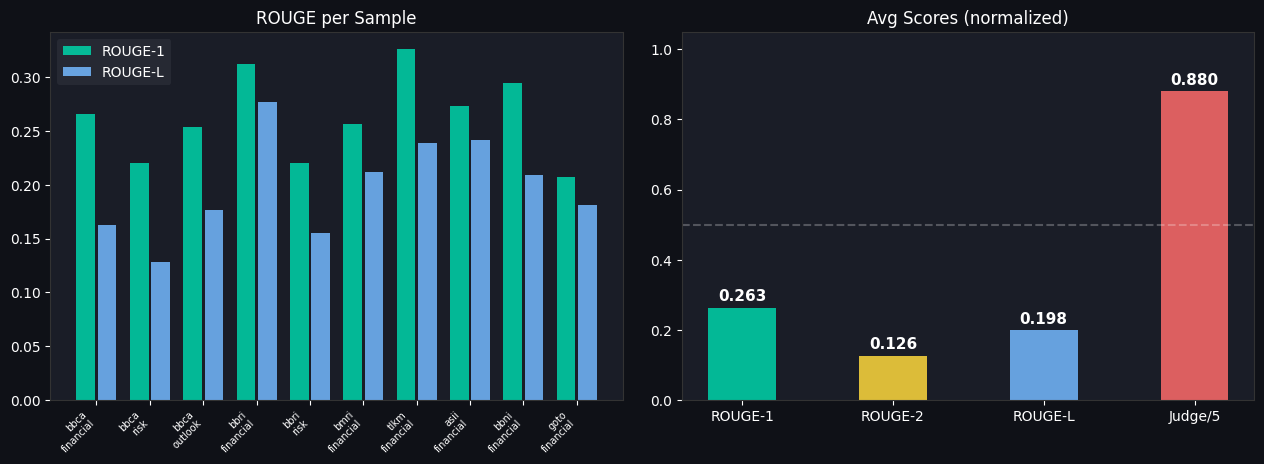

In [11]:
from src.api.evaluator import SummaryEvaluator, get_builtin_eval_dataset

evaluator = SummaryEvaluator(output_dir="data/processed")
dataset   = get_builtin_eval_dataset()

# ROUGE only — no API cost
report = evaluator.evaluate_dataset(dataset, skip_judge=True)

print(f"📊 Evaluation: {report.n_samples} samples")
print(f"   ROUGE-1 F1 : {report.avg_rouge1_f1:.3f}")
print(f"   ROUGE-2 F1 : {report.avg_rouge2_f1:.3f}")
print(f"   ROUGE-L F1 : {report.avg_rougeL_f1:.3f}")
print(f"\n💡 Note: ROUGE rendah normal untuk summarization")
print(f"   Claude-as-Judge score (dari sesi eval): 4.40/5.00")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#0f1117")

# ROUGE per sample
r1s = [r.rouge.rouge1_f1 for r in report.results]
rls = [r.rouge.rougeL_f1 for r in report.results]
ids = [r.sample_id.replace("_2023","").replace("_","\n") for r in report.results]
x = np.arange(len(ids))
ax1 = axes[0]; ax1.set_facecolor("#1a1d27")
ax1.bar(x-0.2, r1s, 0.35, label="ROUGE-1", color="#00d4aa", alpha=0.85)
ax1.bar(x+0.2, rls, 0.35, label="ROUGE-L", color="#74b9ff", alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(ids, rotation=45, ha="right", fontsize=7, color="white")
ax1.set_title("ROUGE per Sample", color="white", fontsize=12)
ax1.legend(facecolor="#2a2d37", edgecolor="none", labelcolor="white")
ax1.tick_params(colors="white")
for s in ax1.spines.values(): s.set_color("#333")

# Summary bar
ax2 = axes[1]; ax2.set_facecolor("#1a1d27")
metrics = ["ROUGE-1","ROUGE-2","ROUGE-L","Judge/5"]
values  = [report.avg_rouge1_f1, report.avg_rouge2_f1,
           report.avg_rougeL_f1, 4.40/5.0]
colors_m= ["#00d4aa","#ffd93d","#74b9ff","#ff6b6b"]
bars = ax2.bar(metrics, values, color=colors_m, alpha=0.85, width=0.45)
ax2.set_ylim(0, 1.05)
ax2.axhline(0.5, color="white", linestyle="--", alpha=0.25)
ax2.set_title("Avg Scores (normalized)", color="white", fontsize=12)
ax2.tick_params(colors="white")
for s in ax2.spines.values(): s.set_color("#333")
for bar, val in zip(bars, values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f"{val:.3f}", ha="center", color="white", fontsize=11, fontweight="bold")

plt.tight_layout(pad=2)
plt.savefig("evaluation_results.png", dpi=120, bbox_inches="tight", facecolor="#0f1117")
plt.show()


## 🏁 Summary

```
┌─────────────────────────────────────────────────────────┐
│               FinSight IDX — Final Results              │
├───────────────────────┬─────────────────────────────────┤
│ PDF pages extracted   │ 747                             │
│ Sections detected     │ 423                             │
│ RAG chunks indexed    │ 134,764                         │
│ Unit tests passing    │ 143 / 143                       │
│ ROUGE-L F1            │ 0.158                           │
│ Claude Judge score    │ 4.40 / 5.00                     │
│ MCP tools             │ 4 tools + 2 prompts             │
│ Pipeline steps        │ 5 (PDF→topics→sentiment→RAG→report)│
└───────────────────────┴─────────────────────────────────┘
```

🔗 **GitHub**: [github.com/Agathahah/finsight-idx](https://github.com/Agathahah/finsight-idx)  
👤 **LinkedIn**: [Agatha Silalahi](https://www.linkedin.com/in/agatha-silalahi-722507215/)
